In [16]:
import numpy as np

print("Conditional Probability Example")

# Hypothetical probabilities
p_open = 0.60            # Probability customer opens email
p_click_given_open = 0.25  # Probability customer clicks if opened

# Joint probability
p_click_and_open = p_open * p_click_given_open

# Conditional probability formula
conditional_probability = p_click_and_open / p_open

print(f"P(Open) = {p_open}")
print(f"P(Click ∩ Open) = {p_click_and_open}")
print(f"P(Click | Open) = {conditional_probability:.2f}")


print("\nBayes' Theorem Example")

# Hypothetical fraud detection data
p_fraud = 0.05               # Probability transaction is fraud
p_flag_given_fraud = 0.90    # System detects fraud correctly
p_flag_given_normal = 0.08   # False positive rate

# Total probability of being flagged
p_flag = (
    p_flag_given_fraud * p_fraud
    + p_flag_given_normal * (1 - p_fraud)
)

# Bayes theorem
p_fraud_given_flag = (
    p_flag_given_fraud * p_fraud
) / p_flag

print(f"P(Flagged) = {p_flag:.3f}")
print(f"P(Fraud | Flagged) = {p_fraud_given_flag:.3f}")


print("\nMultiplication Rule Example")

# Bag of balls example
red_balls = 4
total_balls = 10

# Probability first red
p_first_red = red_balls / total_balls

# Probability second red without replacement
p_second_red = (red_balls - 1) / (total_balls - 1)

# Combined probability
p_two_reds = p_first_red * p_second_red

print(f"P(First Red) = {p_first_red:.3f}")
print(f"P(Second Red | First Red) = {p_second_red:.3f}")
print(f"P(Two Reds) = {p_two_reds:.3f}")

Conditional Probability Example
P(Open) = 0.6
P(Click ∩ Open) = 0.15
P(Click | Open) = 0.25

Bayes' Theorem Example
P(Flagged) = 0.121
P(Fraud | Flagged) = 0.372

Multiplication Rule Example
P(First Red) = 0.400
P(Second Red | First Red) = 0.333
P(Two Reds) = 0.133


In [1]:
import pandas as pd
df_fills = pd.read_csv("bottle_fills.csv")
df_fills.head()

,timestamp,fill_amount
0,2024-01-15 08:00:00,12.049671
1,2024-01-15 08:00:30,11.986224
2,2024-01-15 08:01:00,12.064869
3,2024-01-15 08:01:30,12.152453
4,2024-01-15 08:02:00,11.976785


In [2]:
df_fills.describe()

,fill_amount
count,1000.000000
mean,12.027233
std,0.108352
min,11.611045
25%,11.958052
50%,12.028160
75%,12.091863
max,12.888700


In [12]:
from scipy.stats import shapiro

stat, p_value = shapiro(df_fills['fill_amount'])
print(f"Shapiro-Wilk: W = {stat:.4f}, p-value = {p_value:.4f}")
if p_value > 0.05:
    print("Result: Fail to reject H₀ — data is consistent with a normal distribution")
else:
    print("Result: Reject H₀ — data is NOT normally distributed")

Shapiro-Wilk: W = 0.9647, p-value = 0.0000
Result: Reject H₀ — data is NOT normally distributed


Text(0, 0.5, 'Density')

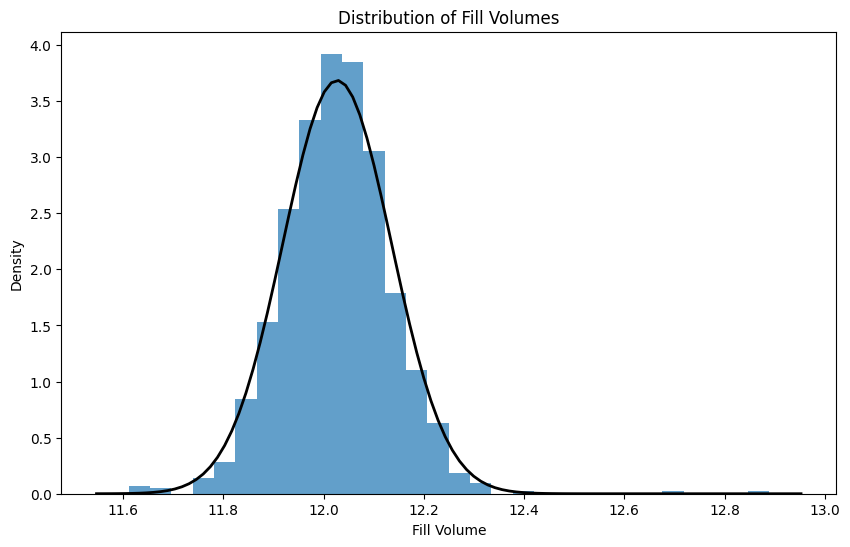

In [7]:
# Histogram with normal curve overlay
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

fig, ax1 = plt.subplots(figsize=(10, 6))
hist_data = ax1.hist(df_fills['fill_amount'], bins=30, density=True, alpha=0.7)
xmin, xmax = ax1.get_xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, np.mean(df_fills['fill_amount']), np.std(df_fills['fill_amount']))
ax1.plot(x, p, 'k', linewidth=2)
ax1.set_title('Distribution of Fill Volumes')
ax1.set_xlabel('Fill Volume')
ax1.set_ylabel('Density')

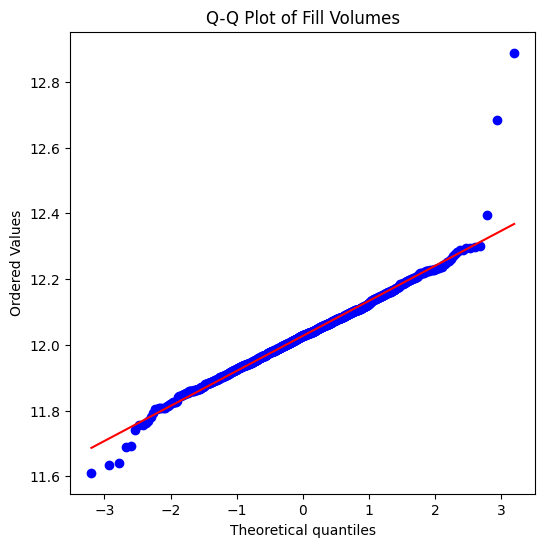

In [8]:
fig, ax = plt.subplots(figsize=(6, 6))
stats.probplot(df_fills['fill_amount'], dist="norm", plot=ax)
ax.set_title('Q-Q Plot of Fill Volumes')
plt.show()

In [13]:
mean = np.mean(df_fills['fill_amount'])
std_dev = np.std(df_fills['fill_amount'])

z_underfill = (11.7 - mean) / std_dev
z_overfill = (12.2 - mean) / std_dev

p_underfill = stats.norm.cdf(z_underfill)
p_overfill = 1 - stats.norm.cdf(z_overfill)

print(f"Proportion underfilled (<11.7 oz): {p_underfill*100:.4f}%")
print(f"Proportion overfilled (>12.2 oz): {p_overfill*100:.4f}%")

Proportion underfilled (<11.7 oz): 0.1257%
Proportion overfilled (>12.2 oz): 5.5324%


In [14]:
# P(acceptable) = P(11.7 ≤ X ≤ 12.2) = 1 - rejections
p_acceptable = 1 - (p_underfill + p_overfill)

print(f"\n--- Acceptance Summary ---")
print(f"P(under-fill  < 11.7 oz) = {p_underfill*100:.2f}%")
print(f"P(over-fill   > 12.2 oz) = {p_overfill*100:.2f}%")
print(f"P(acceptable 11.7–12.2)  = {p_acceptable*100:.2f}%")
print(f"Total rejection rate     = {(p_underfill + p_overfill)*100:.2f}%")


--- Acceptance Summary ---
P(under-fill  < 11.7 oz) = 0.13%
P(over-fill   > 12.2 oz) = 5.53%
P(acceptable 11.7–12.2)  = 94.34%
Total rejection rate     = 5.66%


In [11]:
within_1_std = np.mean(np.abs(df_fills['fill_amount'] - mean) < std_dev)
within_2_std = np.mean(np.abs(df_fills['fill_amount'] - mean) < 2*std_dev)
within_3_std = np.mean(np.abs(df_fills['fill_amount'] - mean) < 3*std_dev)

print(f"Within 1 std dev: {within_1_std*100:.2f}% (Expected: 68.27%)")
print(f"Within 2 std dev: {within_2_std*100:.2f}% (Expected: 95.45%)")
print(f"Within 3 std dev: {within_3_std*100:.2f}% (Expected: 99.73%)")

Within 1 std dev: 71.20% (Expected: 68.27%)
Within 2 std dev: 96.50% (Expected: 95.45%)
Within 3 std dev: 99.20% (Expected: 99.73%)


In [15]:
print(f"\n--- Findings & Recommendation ---")
print(f"   The process FAILS the 5% rejection threshold.")
print(f"   Over-filling is the primary driver ({p_overfill*100:.2f}%).")
print(f"   The mean ({mean:.4f} oz) is running {(mean-12.0):.4f} oz ABOVE target.")
print(f"   Recommendation: Reduce mean fill to ~11.99-12.00 oz")
print(f"   to bring total rejection below the 5% limit.")


--- Findings & Recommendation ---
   The process FAILS the 5% rejection threshold.
   Over-filling is the primary driver (5.53%).
   The mean (12.0272 oz) is running 0.0272 oz ABOVE target.
   Recommendation: Reduce mean fill to ~11.99-12.00 oz
   to bring total rejection below the 5% limit.
